In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/dataset_fraude.csv')
df.head()

,id_cliente,tipo_cliente,edad_cliente,customer_country,customer_region,tenure,importe_medio_mensual,desviacion_estandar_mensual,media_transacciones_al_dia,numero_fraudes_ultimo_ano,...,identificador_dispositivo_fingerprint,dispositivo_reconocido,operacion_pais,operacion_region,direccion_ip_origen,geolocalizacion,cuenta_destino,destino_alto_riesgo,IS_FRAUD,IMPACTO_FRAUDE
0,3ddebd45-ccd,empresa,57,ES,Centro,3364,21.97,292.59,1.58,0,...,fa1bdf50-1c95-45,1,ES,Centro,86.34.12.179,"40.4168,-3.7038",ES169540317577,0,0,0
1,12625769-3f8,persona,68,FR,Normandía,2068,283.70,1425.40,2.99,0,...,1d0337cd-8f7a-42,1,FR,Bretaña,90.14.61.52,"48.8566,2.3522",ES735546725072,1,0,0
2,b5768bae-00f,persona,62,PT,Oporto,1671,83.21,537.38,11.62,0,...,0bf03526-6f4e-42,1,PT,Oporto,85.128.118.137,"41.1579,-8.6291",ES833936678283,0,0,0
3,c3a35556-977,persona,79,ES,Este,3436,575.25,270.19,4.76,0,...,29a17329-bcec-42,1,ES,Sur,86.56.138.66,"40.4168,-3.7038",ES642797821786,0,0,0
4,46b228e3-b47,persona,73,DE,Hesse,3557,171.31,302.57,4.00,0,...,5854151e-c36e-41,1,DE,Hesse,87.220.5.4,"52.5200,13.4050",ES973327198270,0,0,0


In [3]:
if 'IMPACTO_FRAUDE' in df.columns:
    df.drop(columns=['IMPACTO_FRAUDE'], inplace=True)


In [4]:
df['fecha_hora'] = pd.to_datetime(df['fecha_hora'])

df['fecha'] = df['fecha_hora'].dt.date
df['hora'] = df['fecha_hora'].dt.hour
df['dia_semana'] = df['fecha_hora'].dt.day_name()
df['mes'] = df['fecha_hora'].dt.month

In [5]:
df.isna().sum().sort_values(ascending=False)

id_cliente                                0
tipo_cliente                              0
edad_cliente                              0
customer_country                          0
customer_region                           0
tenure                                    0
importe_medio_mensual                     0
desviacion_estandar_mensual               0
media_transacciones_al_dia                0
numero_fraudes_ultimo_ano                 0
id_cuenta                                 0
cuenta_origen                             0
estado_cuenta                             0
saldo_actual                              0
saldo_medio_30_dias                       0
volumen_entrante_30_dias                  0
volumen_saliente_30_dias                  0
numero_transferencias_recibidas_7_dias    0
numero_transferencias_enviadas_7_dias     0
id_tarjeta                                0
estado_tarjeta                            0
fecha_creacion_tarjeta                    0
antiguedad_tarjeta_dias         

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 48 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   id_cliente                              10000 non-null  str           
 1   tipo_cliente                            10000 non-null  str           
 2   edad_cliente                            10000 non-null  int64         
 3   customer_country                        10000 non-null  str           
 4   customer_region                         10000 non-null  str           
 5   tenure                                  10000 non-null  int64         
 6   importe_medio_mensual                   10000 non-null  float64       
 7   desviacion_estandar_mensual             10000 non-null  float64       
 8   media_transacciones_al_dia              10000 non-null  float64       
 9   numero_fraudes_ultimo_ano               10000 non-null  int64 

In [7]:
df.describe()

,edad_cliente,tenure,importe_medio_mensual,desviacion_estandar_mensual,media_transacciones_al_dia,numero_fraudes_ultimo_ano,saldo_actual,saldo_medio_30_dias,volumen_entrante_30_dias,volumen_saliente_30_dias,...,is_weekend,tiempo_desde_ultima_transaccion,numero_transacciones_ultima_hora,importe_transaccion,numero_pin_disponibles,dispositivo_reconocido,destino_alto_riesgo,IS_FRAUD,hora,mes
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,...,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,51.228900,1801.225000,860.610553,487.970697,3.345459,0.455700,3339.609429,3283.838537,9065.748711,1.040320e+04,...,0.284300,1.360110e+06,2.008100,473.109818,1.848100,0.849200,0.118900,0.152600,11.471200,4.957900
min,18.000000,1.000000,6.930000,0.080000,0.500000,0.000000,1.350000,1.460000,20.660000,1.277000e+01,...,0.000000,0.000000e+00,0.000000,0.520000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,34.000000,869.000000,192.380000,147.020000,1.340000,0.000000,401.210000,387.970000,1094.777500,1.132023e+03,...,0.000000,0.000000e+00,1.000000,54.382500,1.000000,1.000000,0.000000,0.000000,5.000000,2.000000
50%,50.000000,1792.000000,430.980000,352.380000,2.500000,0.000000,1024.610000,1043.840000,2964.450000,3.070215e+03,...,0.000000,4.361600e+04,2.000000,148.475000,2.000000,1.000000,0.000000,0.000000,11.000000,4.000000
75%,69.000000,2736.500000,956.230000,681.030000,4.430000,1.000000,2928.127500,2911.290000,8159.335000,8.401372e+03,...,1.000000,1.579065e+05,3.000000,409.747500,2.000000,1.000000,0.000000,0.000000,18.000000,5.000000
max,84.000000,3647.000000,44868.230000,4150.160000,22.450000,6.000000,294122.030000,325718.190000,609238.470000,1.501301e+06,...,1.000000,1.542519e+07,9.000000,27088.380000,3.000000,1.000000,1.000000,1.000000,23.000000,12.000000
std,19.861006,1051.031019,1741.871375,476.583989,2.810975,0.784282,9546.123277,9149.502512,24365.369485,4.551894e+04,...,0.451103,2.956285e+06,1.427459,1177.443036,0.726828,0.357872,0.323687,0.359619,6.955775,3.945945


In [8]:
df["importe_transaccion"].describe()

count    10000.000000
mean       473.109818
std       1177.443036
min          0.520000
25%         54.382500
50%        148.475000
75%        409.747500
max      27088.380000
Name: importe_transaccion, dtype: float64

In [9]:
print('Columnas del dataset:')
print(df.columns.tolist())

Columnas del dataset:
['id_cliente', 'tipo_cliente', 'edad_cliente', 'customer_country', 'customer_region', 'tenure', 'importe_medio_mensual', 'desviacion_estandar_mensual', 'media_transacciones_al_dia', 'numero_fraudes_ultimo_ano', 'id_cuenta', 'cuenta_origen', 'estado_cuenta', 'saldo_actual', 'saldo_medio_30_dias', 'volumen_entrante_30_dias', 'volumen_saliente_30_dias', 'numero_transferencias_recibidas_7_dias', 'numero_transferencias_enviadas_7_dias', 'id_tarjeta', 'estado_tarjeta', 'fecha_creacion_tarjeta', 'antiguedad_tarjeta_dias', 'limite_importe_transacciones', 'veces_superar_limite_7_dias', 'id_transaccion', 'tipo_transaccion', 'fecha_hora', 'is_night', 'is_weekend', 'tiempo_desde_ultima_transaccion', 'numero_transacciones_ultima_hora', 'importe_transaccion', 'metodo_autenticacion', 'numero_pin_disponibles', 'identificador_dispositivo_fingerprint', 'dispositivo_reconocido', 'operacion_pais', 'operacion_region', 'direccion_ip_origen', 'geolocalizacion', 'cuenta_destino', 'destin

In [10]:
categorical_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

print('Columnas categÃ³ricas:')
print(categorical_cols)


Columnas categÃ³ricas:
['id_cliente', 'tipo_cliente', 'customer_country', 'customer_region', 'id_cuenta', 'cuenta_origen', 'estado_cuenta', 'id_tarjeta', 'estado_tarjeta', 'fecha_creacion_tarjeta', 'id_transaccion', 'tipo_transaccion', 'metodo_autenticacion', 'identificador_dispositivo_fingerprint', 'operacion_pais', 'operacion_region', 'direccion_ip_origen', 'geolocalizacion', 'cuenta_destino', 'fecha', 'dia_semana']


In [11]:
fraud_rate_hora = (
    df.groupby('hora')['IS_FRAUD']
    .mean()
    .reset_index(name='fraud_rate')
)

fraud_rate_dia_semana = (
    df.groupby('dia_semana')['IS_FRAUD']
    .mean()
    .reset_index(name='fraud_rate')
)

orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fraud_rate_dia_semana['dia_semana'] = pd.Categorical(
    fraud_rate_dia_semana['dia_semana'],
    categories=orden_dias,
    ordered=True
)
fraud_rate_dia_semana = fraud_rate_dia_semana.sort_values('dia_semana')

fraud_rate_mes = (
    df.groupby('mes')['IS_FRAUD']
    .mean()
    .reset_index(name='fraud_rate')
)

print("Fraud rate por hora")
display(fraud_rate_hora)

print("Fraud rate por día de la semana")
display(fraud_rate_dia_semana)

print("Fraud rate por mes")
display(fraud_rate_mes)

Fraud rate por hora


,hora,fraud_rate
0,0,0.154930
1,1,0.133995
2,2,0.200466
3,3,0.158621
4,4,0.147343
5,5,0.155606
6,6,0.141204
7,7,0.153659
8,8,0.146512
9,9,0.114058


Fraud rate por día de la semana


,dia_semana,fraud_rate
1,Monday,0.154225
5,Tuesday,0.155680
6,Wednesday,0.152086
4,Thursday,0.159187
0,Friday,0.150107
2,Saturday,0.157153
3,Sunday,0.139747


Fraud rate por mes


,mes,fraud_rate
0,1,0.160494
1,2,0.148990
2,3,0.165143
3,4,0.147531
4,5,0.150087
5,11,0.120690
6,12,0.152824


Columnas encontradas: ['tipo_cliente', 'customer_country', 'customer_region', 'estado_cuenta', 'estado_tarjeta', 'tipo_transaccion', 'metodo_autenticacion', 'operacion_pais', 'operacion_region', 'dia_semana', 'hora', 'mes']
Columnas no encontradas: []


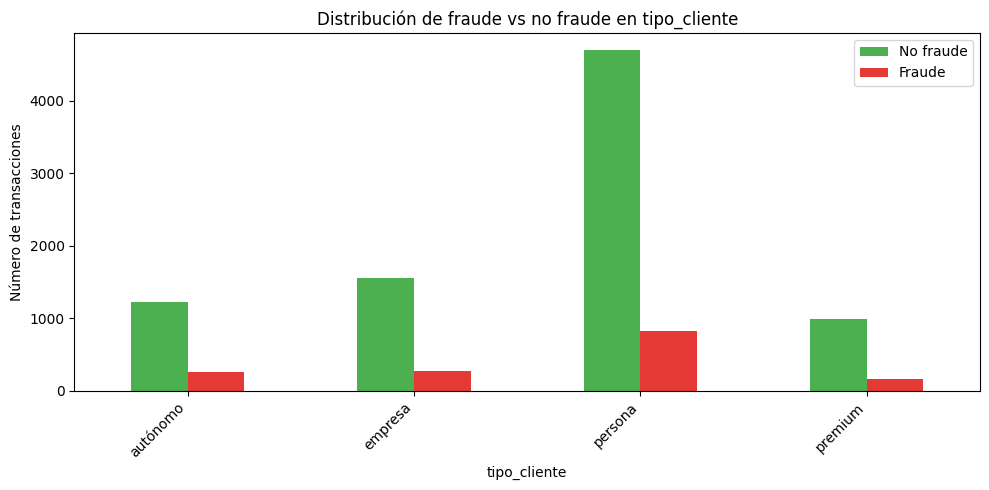

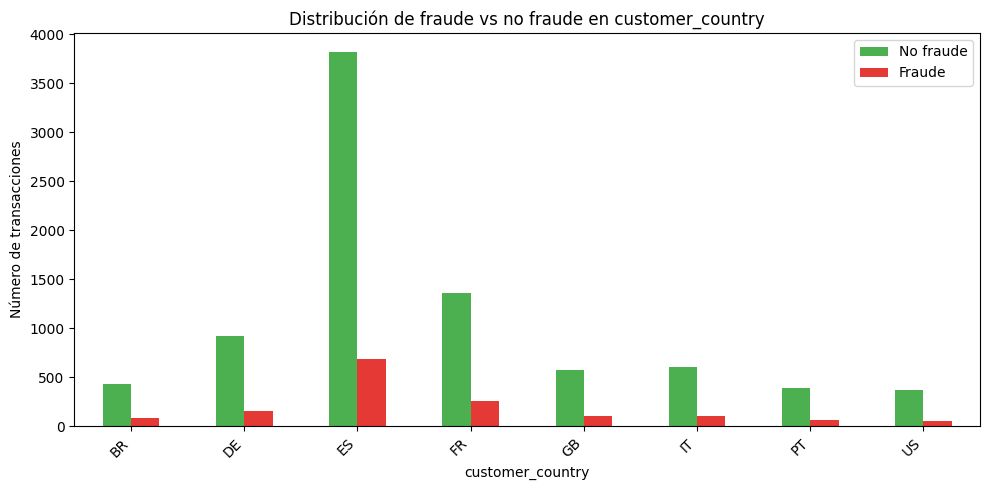

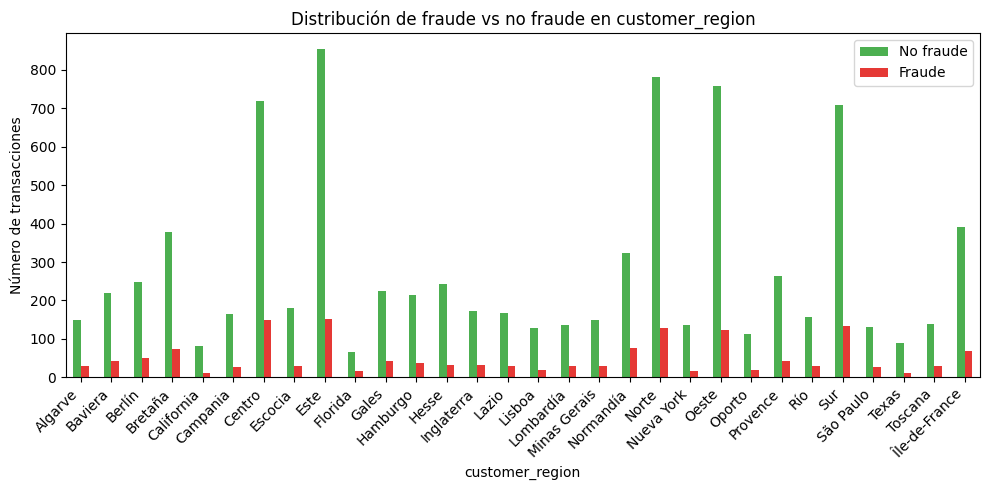

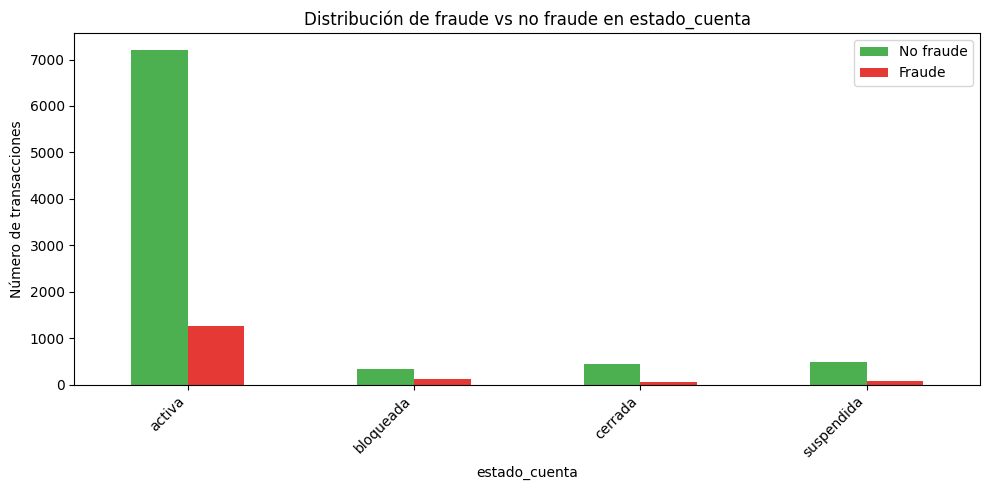

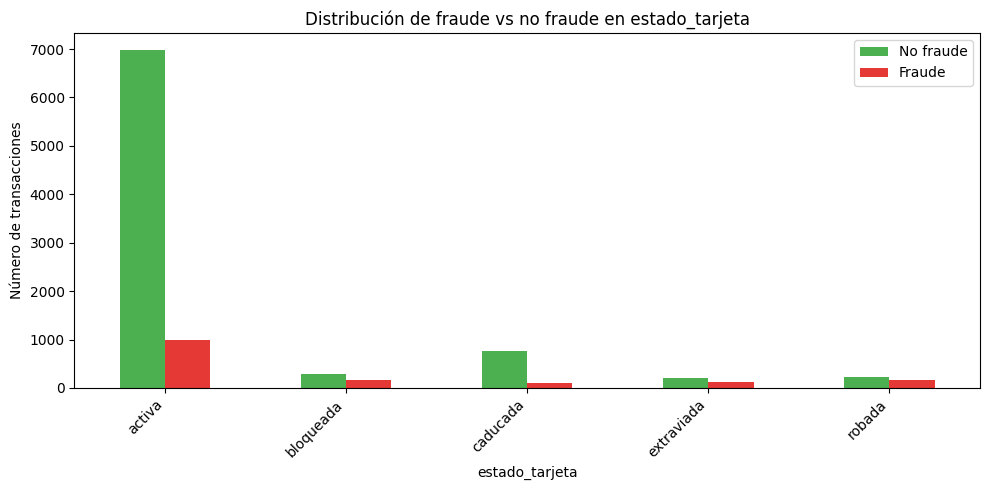

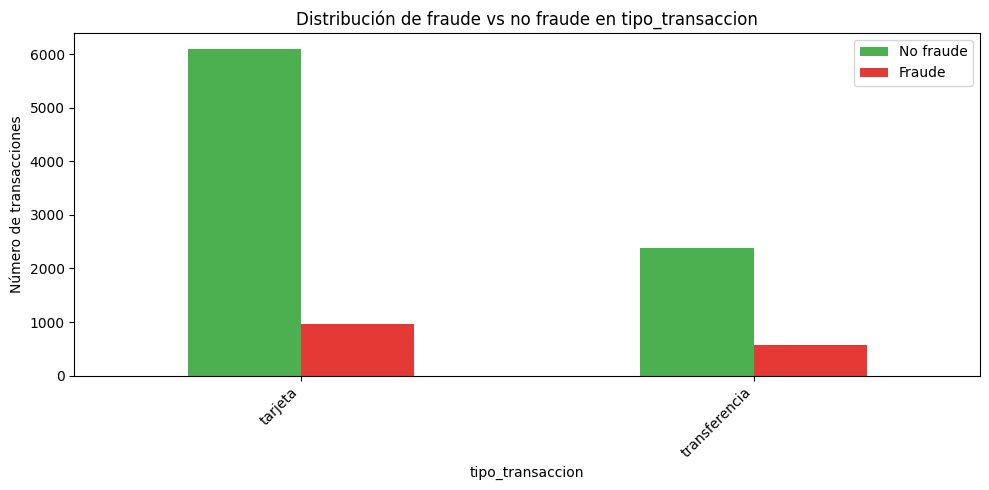

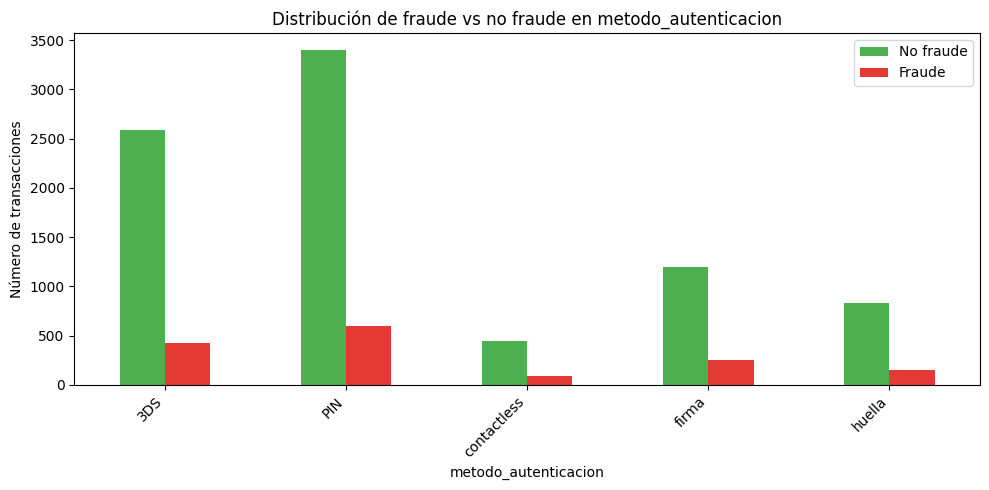

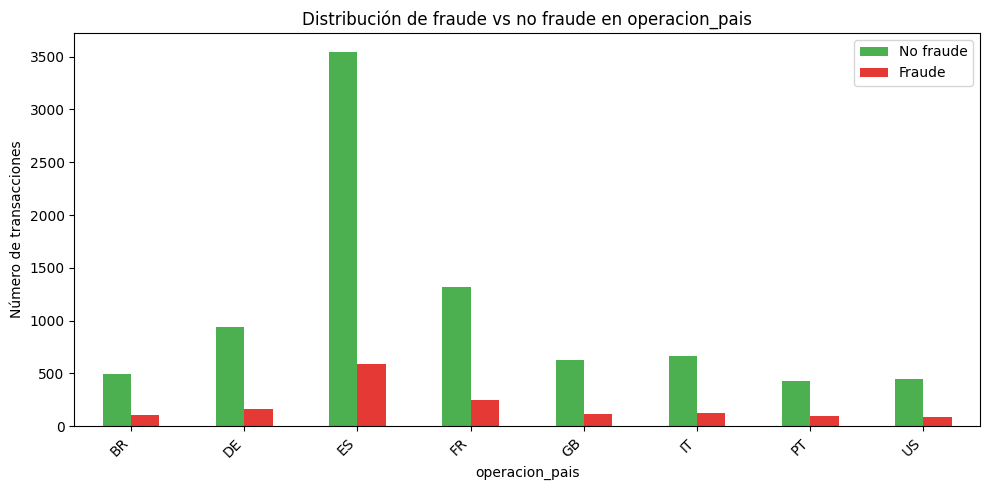

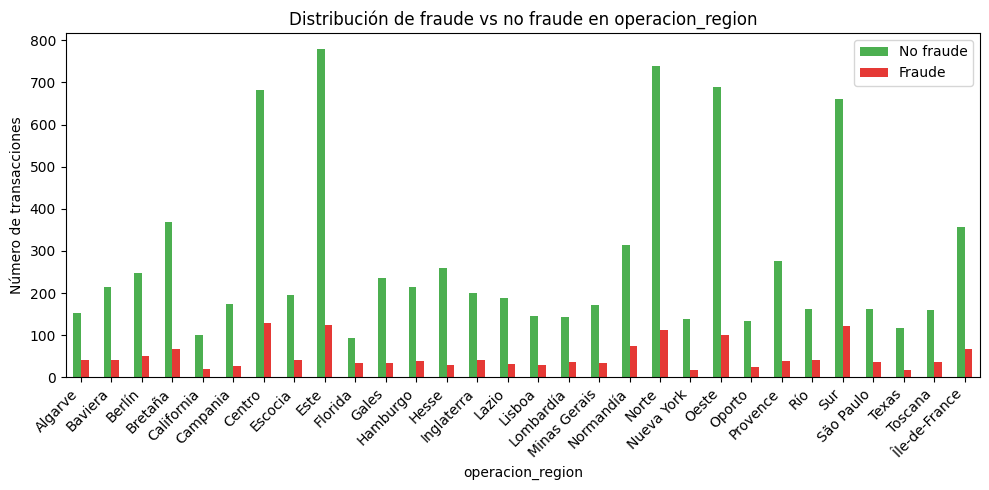

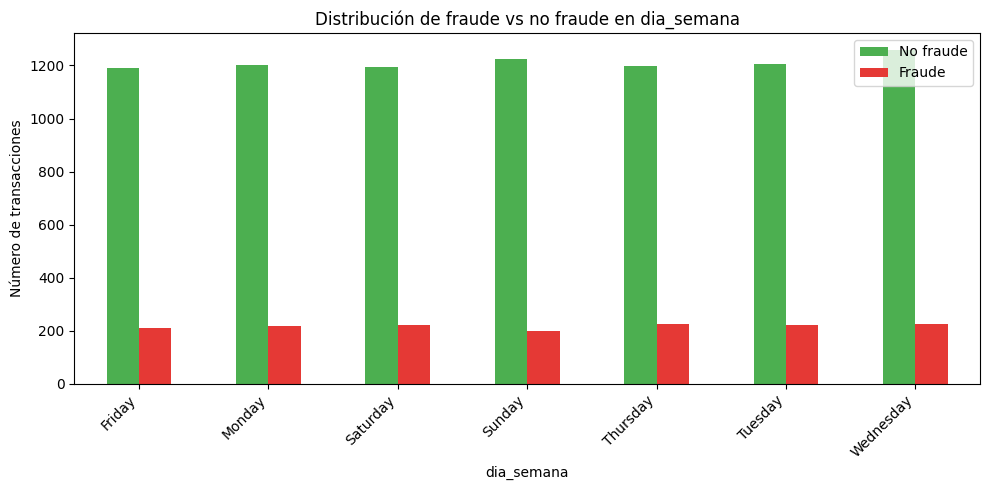

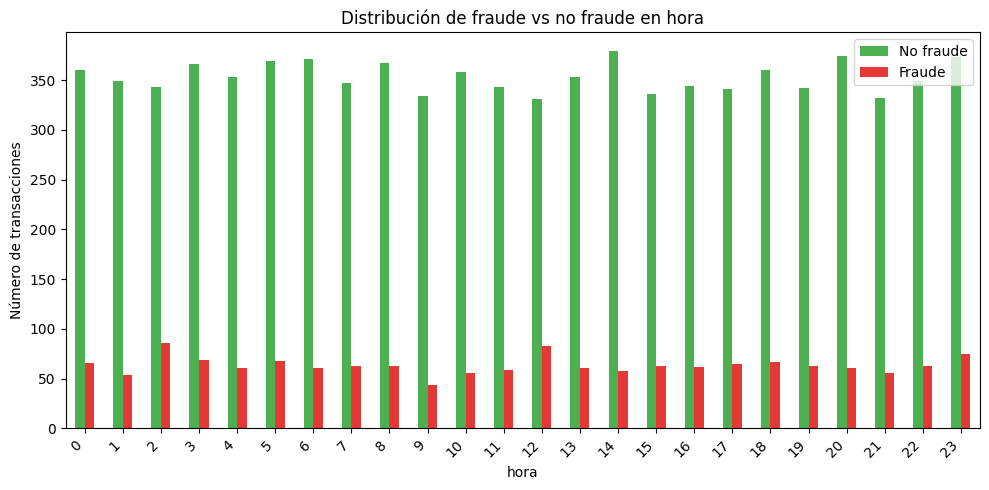

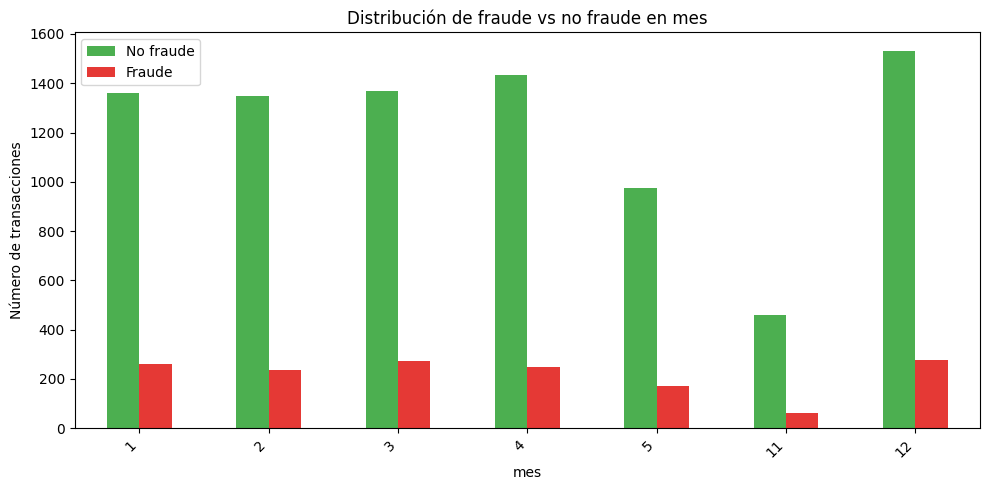

In [12]:
cols_to_plot = [
    'tipo_cliente',
    'customer_country',
    'customer_region',
    'estado_cuenta',
    'estado_tarjeta',
    'tipo_transaccion',
    'metodo_autenticacion',
    'operacion_pais',
    'operacion_region',
    'dia_semana',
    'hora',
    'mes'
]

cols_existentes = [col for col in cols_to_plot if col in df.columns]
cols_faltantes = [col for col in cols_to_plot if col not in df.columns]

print('Columnas encontradas:', cols_existentes)
print('Columnas no encontradas:', cols_faltantes)

for col in cols_existentes:
    tabla = pd.crosstab(df[col], df['IS_FRAUD'])
    tabla = tabla.reindex(columns=[0, 1], fill_value=0)
    tabla.columns = ['No fraude', 'Fraude']

    tabla.plot(kind='bar', figsize=(10, 5), color=['#4CAF50', '#E53935'])
    plt.title(f'Distribución de fraude vs no fraude en {col}')
    plt.xlabel(col)
    plt.ylabel('Número de transacciones')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

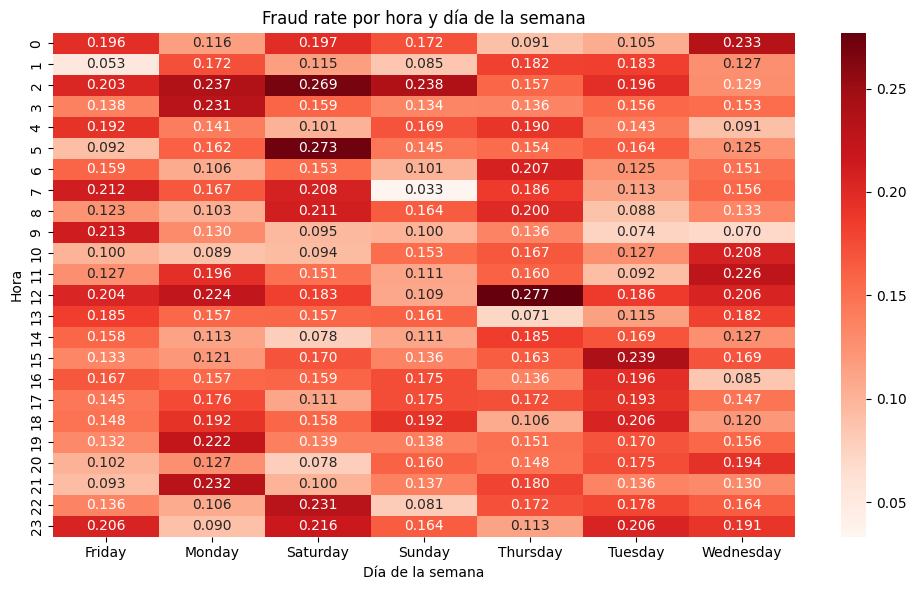

In [13]:
pivot = df.pivot_table(
    values='IS_FRAUD',
    index='hora',
    columns='dia_semana',
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, cmap='Reds', annot=True, fmt='.3f')
plt.title('Fraud rate por hora y día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Hora')
plt.tight_layout()
plt.show()

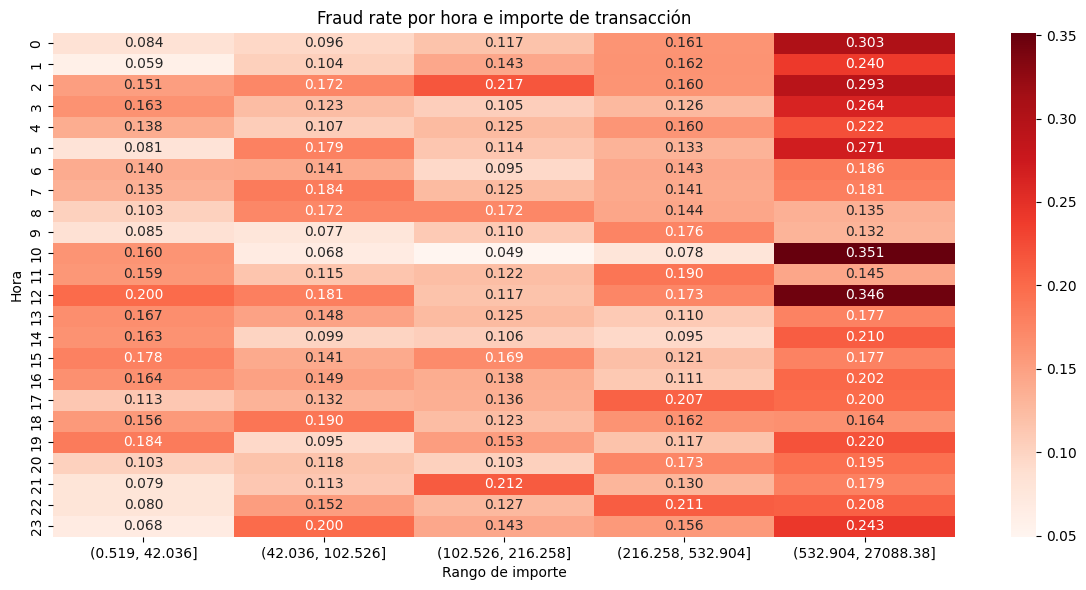

In [14]:
df['importe_bin'] = pd.qcut(df['importe_transaccion'], q=5, duplicates='drop')

pivot_hora_importe = df.pivot_table(
    values='IS_FRAUD',
    index='hora',
    columns='importe_bin',
    aggfunc='mean'
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_hora_importe, cmap='Reds', annot=True, fmt='.3f')
plt.title('Fraud rate por hora e importe de transacción')
plt.xlabel('Rango de importe')
plt.ylabel('Hora')
plt.tight_layout()
plt.show()

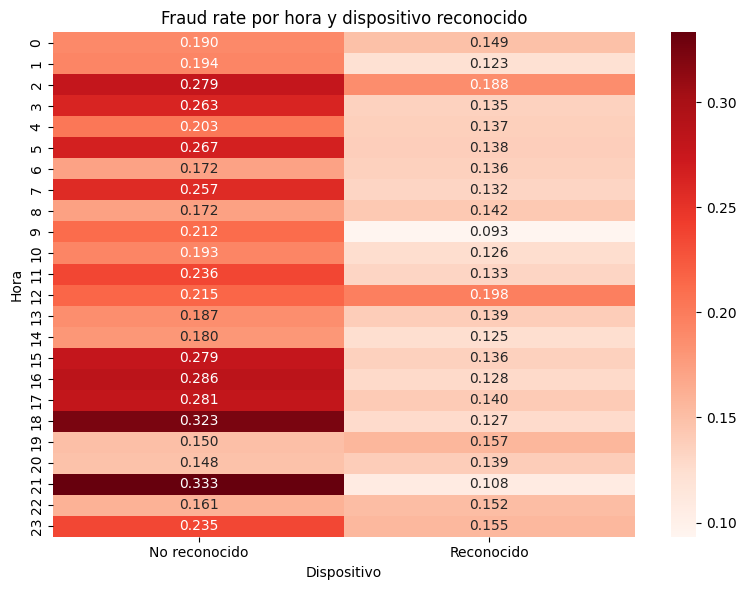

In [15]:
df['dispositivo_label'] = df['dispositivo_reconocido'].map({
    0: 'No reconocido',
    1: 'Reconocido'
})

pivot_hora_dispositivo = df.pivot_table(
    values='IS_FRAUD',
    index='hora',
    columns='dispositivo_label',
    aggfunc='mean'
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_hora_dispositivo, cmap='Reds', annot=True, fmt='.3f')
plt.title('Fraud rate por hora y dispositivo reconocido')
plt.xlabel('Dispositivo')
plt.ylabel('Hora')
plt.tight_layout()
plt.show()

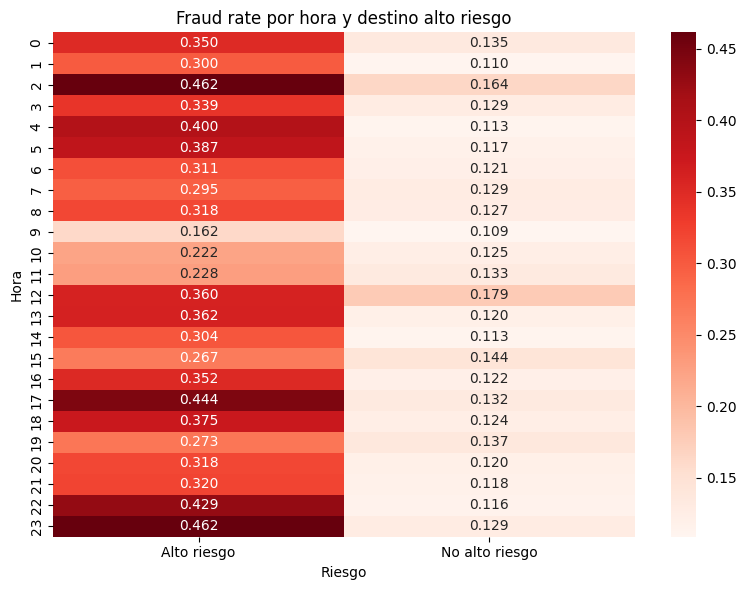

In [16]:
df['riesgo_label'] = df['destino_alto_riesgo'].map({
    0: 'No alto riesgo',
    1: 'Alto riesgo'
})

pivot_hora_riesgo = df.pivot_table(
    values='IS_FRAUD',
    index='hora',
    columns='riesgo_label',
    aggfunc='mean'
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_hora_riesgo, cmap='Reds', annot=True, fmt='.3f')
plt.title('Fraud rate por hora y destino alto riesgo')
plt.xlabel('Riesgo')
plt.ylabel('Hora')
plt.tight_layout()
plt.show()

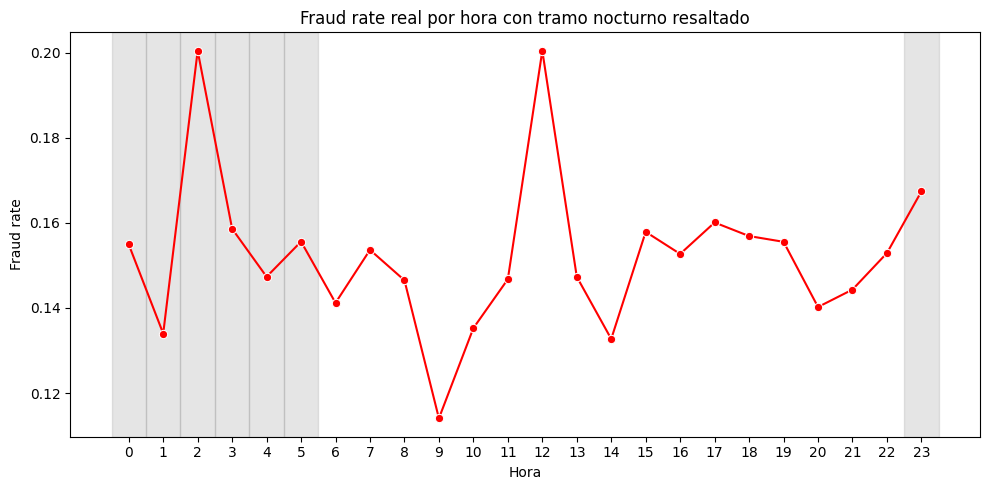

In [17]:
# Lo resaltado = franja is_night
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=fraud_rate_hora,
    x='hora',
    y='fraud_rate',
    marker='o',
    color='red'
)

for h in [23, 0, 1, 2, 3, 4, 5]:
    plt.axvspan(h - 0.5, h + 0.5, color='gray', alpha=0.2)

plt.title('Fraud rate real por hora con tramo nocturno resaltado')
plt.xlabel('Hora')
plt.ylabel('Fraud rate')
plt.xticks(range(24))
plt.tight_layout()
plt.show()

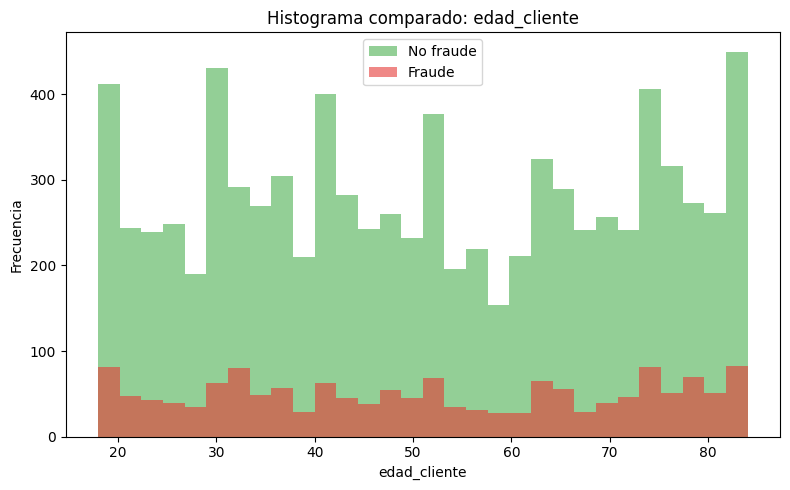

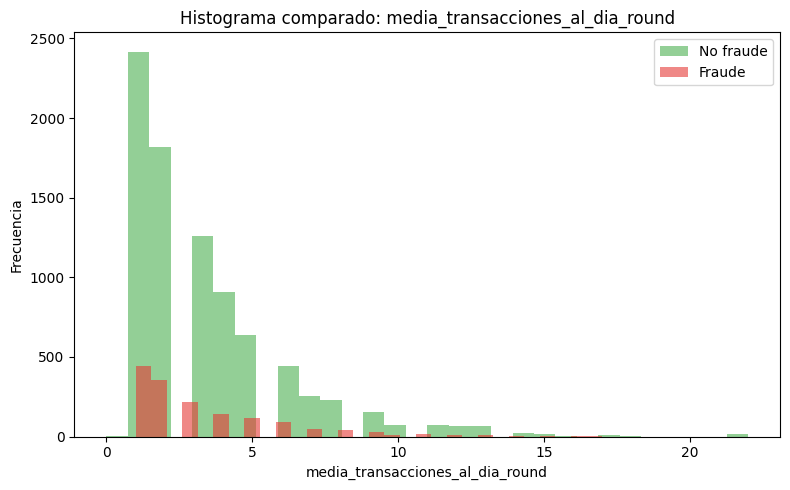

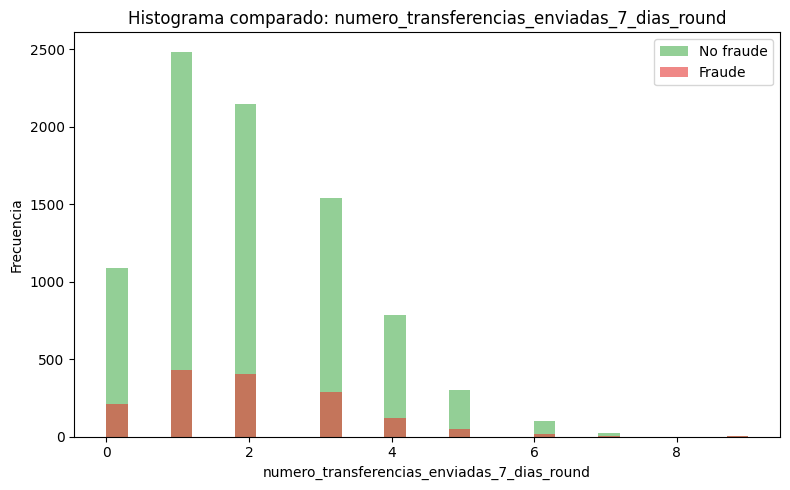

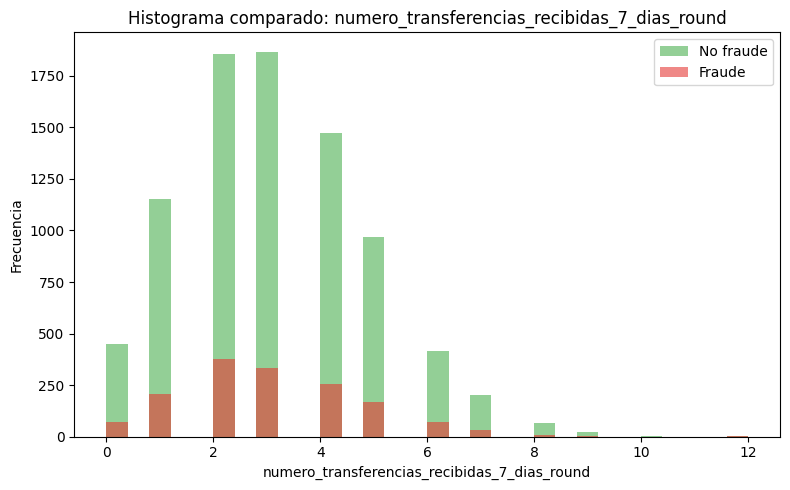

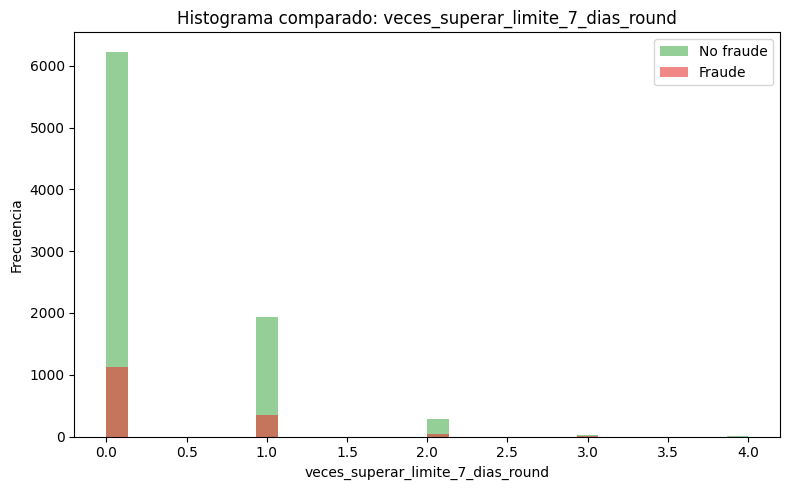

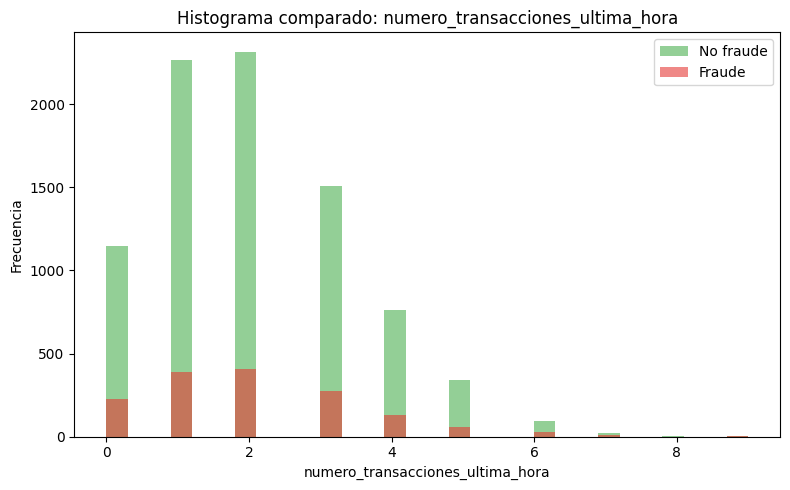

In [18]:
df_plot = df.copy()

df_plot['media_transacciones_al_dia_round'] = df_plot['media_transacciones_al_dia'].round()
df_plot['numero_transferencias_enviadas_7_dias_round'] = df_plot['numero_transferencias_enviadas_7_dias'].round()
df_plot['numero_transferencias_recibidas_7_dias_round'] = df_plot['numero_transferencias_recibidas_7_dias'].round()
df_plot['veces_superar_limite_7_dias_round'] = df_plot['veces_superar_limite_7_dias'].round()

variables = [
    'edad_cliente',
    'media_transacciones_al_dia_round',
    'numero_transferencias_enviadas_7_dias_round',
    'numero_transferencias_recibidas_7_dias_round',
    'veces_superar_limite_7_dias_round',
    'numero_transacciones_ultima_hora'
]

for col in variables:
    plt.figure(figsize=(8, 5))
    
    plt.hist(
        df_plot[df_plot['IS_FRAUD'] == 0][col].dropna(),
        bins=30,
        alpha=0.6,
        label='No fraude',
        color='#4CAF50'
    )
    
    plt.hist(
        df_plot[df_plot['IS_FRAUD'] == 1][col].dropna(),
        bins=30,
        alpha=0.6,
        label='Fraude',
        color='#E53935'
    )
    
    plt.title(f'Histograma comparado: {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.tight_layout()
    plt.show()

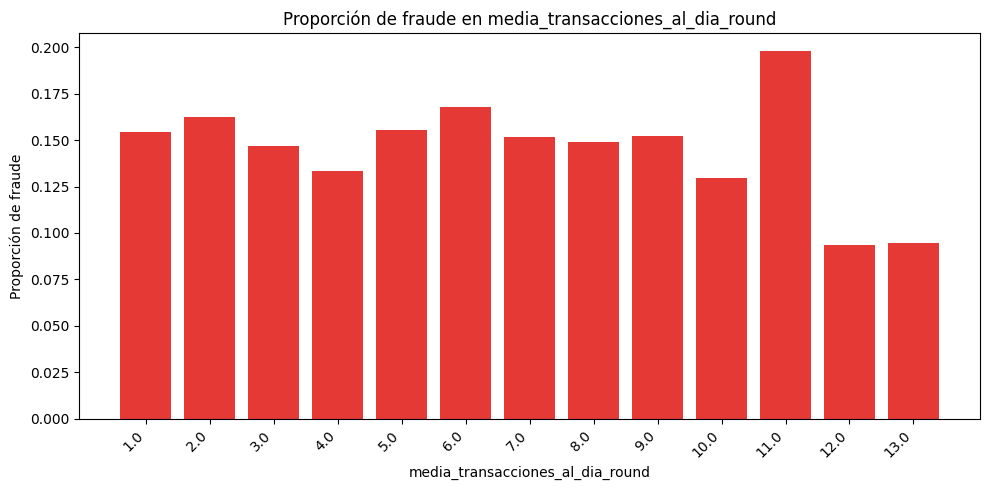

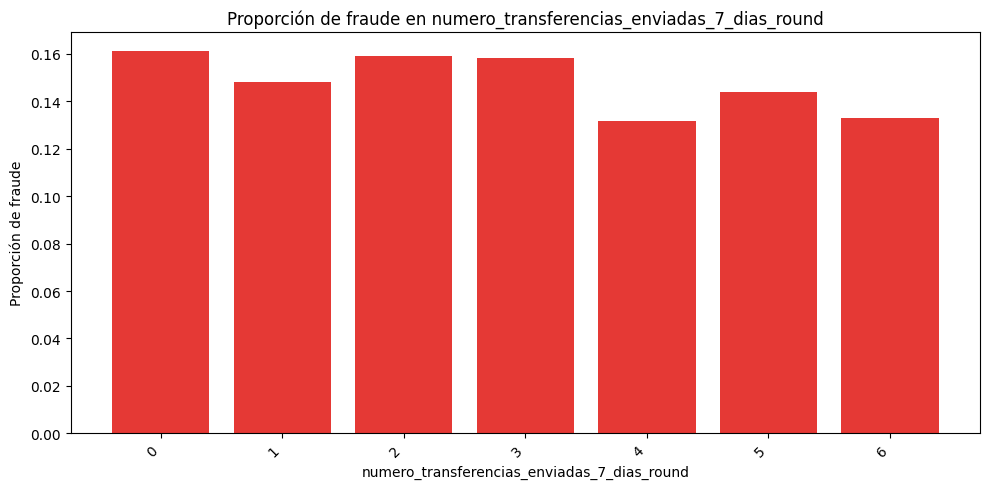

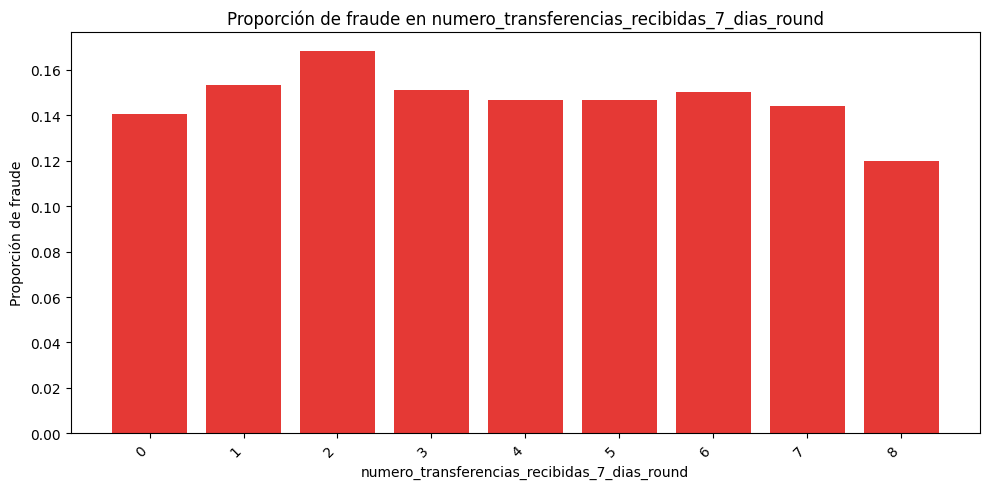

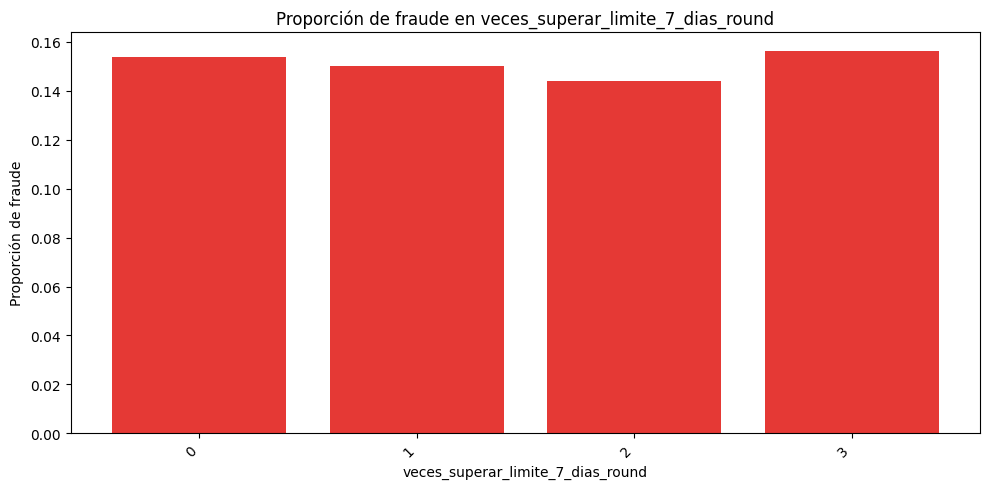

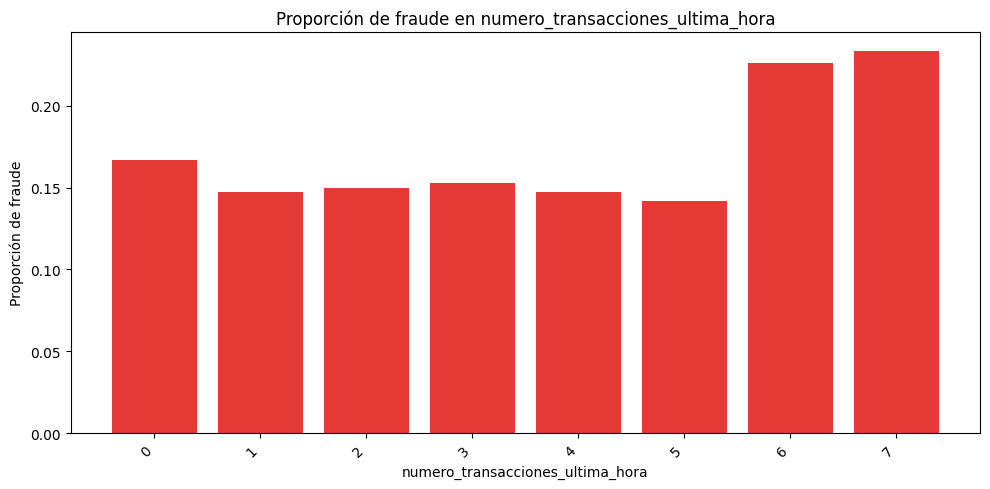

In [19]:
variables = [
    'media_transacciones_al_dia_round',
    'numero_transferencias_enviadas_7_dias_round',
    'numero_transferencias_recibidas_7_dias_round',
    'veces_superar_limite_7_dias_round',
    'numero_transacciones_ultima_hora'
]

min_obs = 30

for col in variables:
    resumen = (
        df_plot.groupby(col, observed=False)
        .agg(
            total=('IS_FRAUD', 'size'),
            fraude_rate=('IS_FRAUD', 'mean')
        )
        .reset_index()
    )

    resumen = resumen[resumen['total'] >= min_obs]
    resumen = resumen.sort_values(col)

    plt.figure(figsize=(10, 5))
    plt.bar(resumen[col].astype(str), resumen['fraude_rate'], color='#E53935')
    plt.title(f'Proporción de fraude en {col}')
    plt.xlabel(col)
    plt.ylabel('Proporción de fraude')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

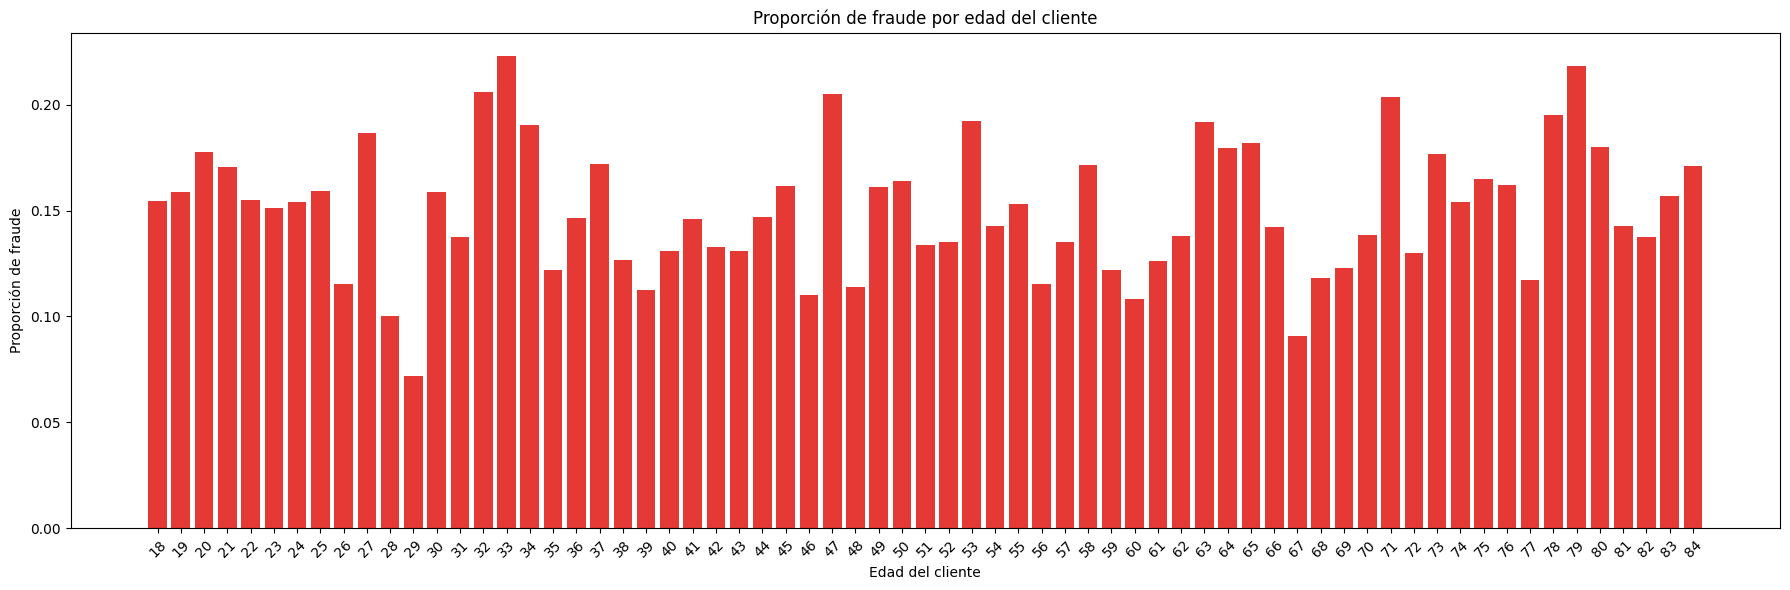

In [20]:
min_obs = 30

resumen_edad = (
    df.groupby('edad_cliente', observed=False)
    .agg(
        total=('IS_FRAUD', 'size'),
        fraude_rate=('IS_FRAUD', 'mean')
    )
    .reset_index()
)

resumen_edad = resumen_edad[resumen_edad['total'] >= min_obs]
resumen_edad = resumen_edad.sort_values('edad_cliente')

plt.figure(figsize=(18, 6))
plt.bar(resumen_edad['edad_cliente'].astype(str), resumen_edad['fraude_rate'], color='#E53935')
plt.title('Proporción de fraude por edad del cliente')
plt.xlabel('Edad del cliente')
plt.ylabel('Proporción de fraude')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
numeric_cols.remove('IS_FRAUD')

corr_target = df[numeric_cols + ['IS_FRAUD']].corr()['IS_FRAUD'].drop('IS_FRAUD')
corr_target = corr_target.sort_values(key=abs, ascending=False)

print(corr_target)

destino_alto_riesgo                       0.187777
dispositivo_reconocido                   -0.086941
importe_transaccion                       0.084366
numero_fraudes_ultimo_ano                 0.038864
importe_medio_mensual                     0.032668
is_night                                  0.013616
numero_pin_disponibles                    0.012932
numero_transferencias_recibidas_7_dias   -0.012812
tenure                                    0.012630
limite_importe_transacciones             -0.012196
mes                                      -0.011541
numero_transferencias_enviadas_7_dias    -0.010818
media_transacciones_al_dia               -0.010290
saldo_medio_30_dias                       0.009384
saldo_actual                              0.008013
tiempo_desde_ultima_transaccion           0.007846
is_weekend                               -0.007300
desviacion_estandar_mensual               0.006042
antiguedad_tarjeta_dias                  -0.005016
veces_superar_limite_7_dias    

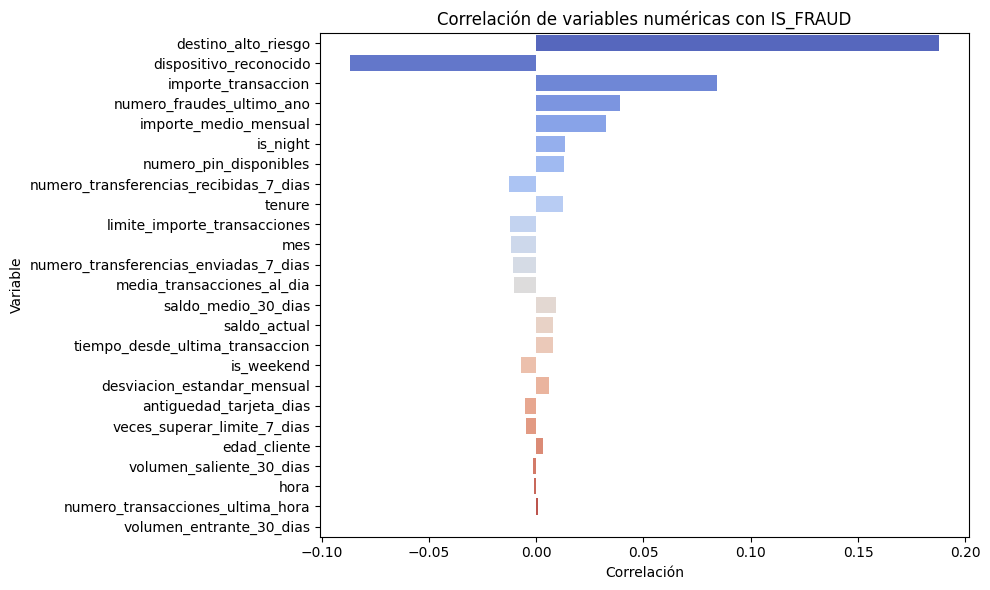

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(x=corr_target.values, y=corr_target.index, hue=corr_target.index, palette='coolwarm', legend=False)
plt.title('Correlación de variables numéricas con IS_FRAUD')
plt.xlabel('Correlación')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

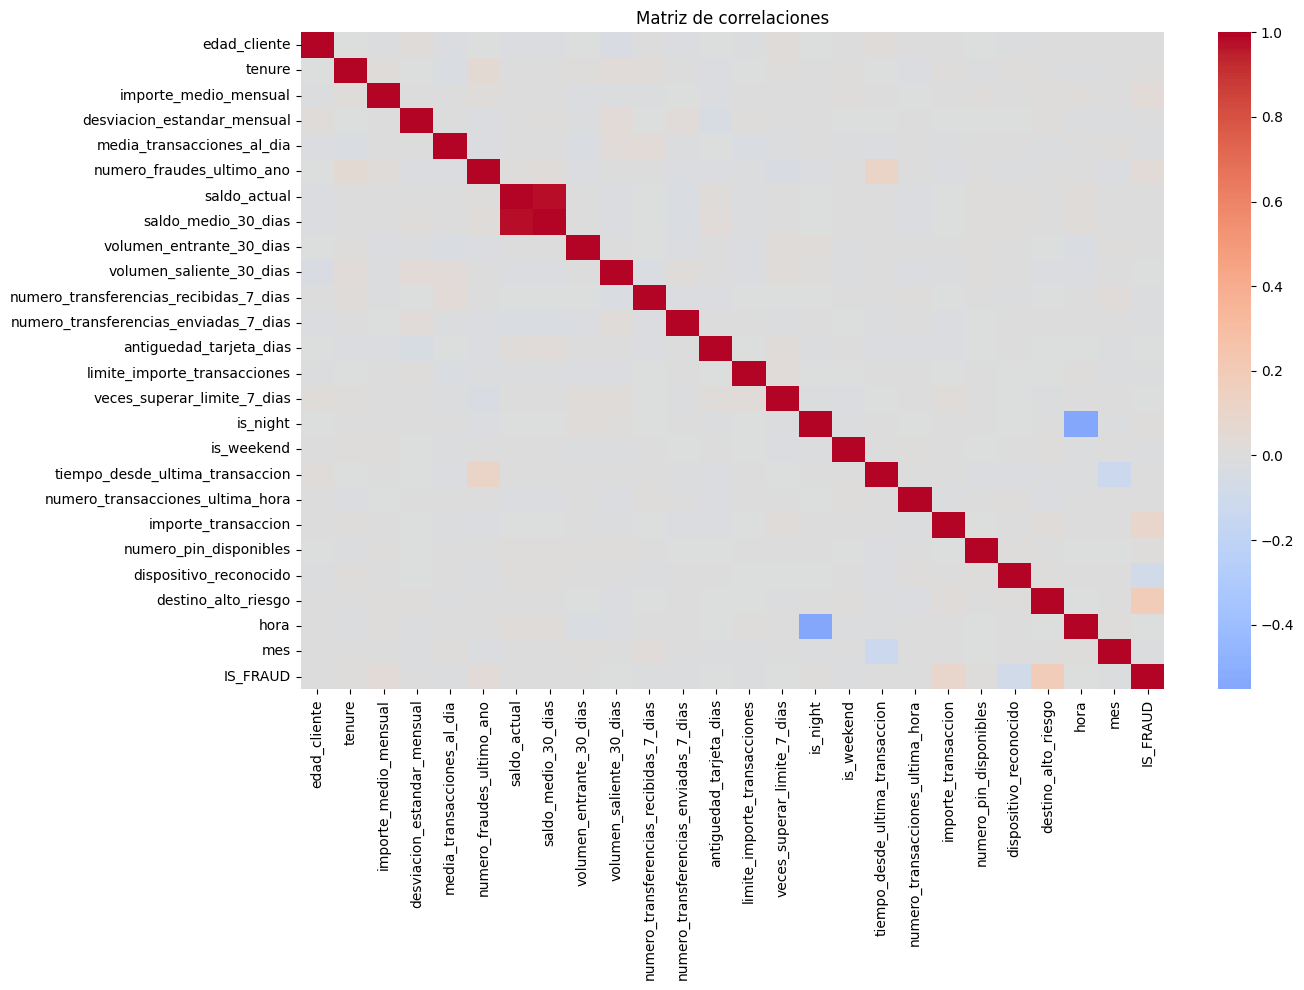

In [23]:
plt.figure(figsize=(14, 10))
sns.heatmap(df[numeric_cols + ['IS_FRAUD']].corr(), cmap='coolwarm', center=0)
plt.title('Matriz de correlaciones')
plt.tight_layout()
plt.show()

In [24]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

# CategÃ³ricas Ãºtiles para anÃ¡lisis
categorical_cols = [
    col for col in df.select_dtypes(include=['object', 'category', 'string']).columns
    if col not in [
        'id_cliente',
        'id_cuenta',
        'id_tarjeta',
        'id_transaccion',
        'direccion_ip_origen',
        'identificador_dispositivo_fingerprint',
        'fecha_hora',
        'fecha_creacion_tarjeta'
    ]
]

def cramers_v(tabla):
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1)))

resultados = []

for col in categorical_cols:
    tabla = pd.crosstab(df[col], df['IS_FRAUD'])

    if tabla.shape[0] > 1 and tabla.shape[1] > 1:
        chi2, p_value, _, _ = chi2_contingency(tabla)
        v = cramers_v(tabla)

        resultados.append({
            'variable': col,
            'n_categorias': df[col].nunique(),
            'cramers_v': v,
            'p_value': p_value
        })

relacion_categoricas = pd.DataFrame(resultados).sort_values('cramers_v', ascending=False)
relacion_categoricas


,variable,n_categorias,cramers_v,p_value
3,cuenta_origen,3548,0.606808,5.561384e-02
11,cuenta_destino,500,0.289926,7.846106e-20
5,estado_tarjeta,5,0.226387,1.317423e-109
16,riesgo_label,2,0.187348,2.577889e-78
12,fecha,183,0.130446,7.255122e-01
14,importe_bin,5,0.094628,1.644673e-18
15,dispositivo_label,2,0.086552,4.920630e-18
4,estado_cuenta,4,0.075266,3.052935e-12
9,operacion_region,30,0.073500,3.216245e-03
6,tipo_transaccion,2,0.072147,5.407263e-13


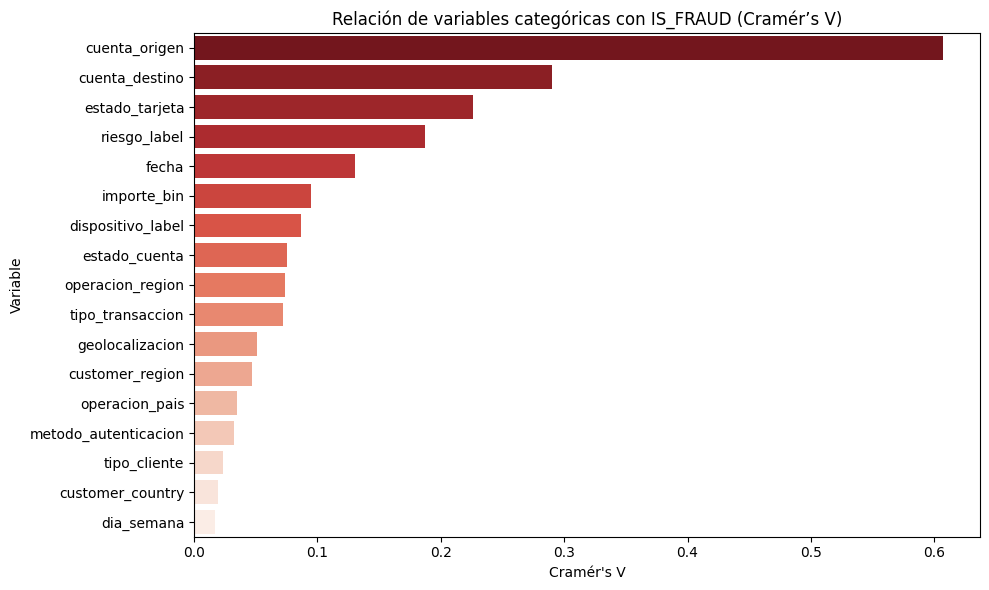

In [25]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=relacion_categoricas,
    x='cramers_v',
    y='variable',
    hue='variable',
    palette='Reds_r',
    legend=False
)
plt.title('Relación de variables categóricas con IS_FRAUD (Cramér’s V)')
plt.xlabel("Cramér's V")
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

In [26]:
df['importe_tramo'] = pd.qcut(
    df['importe_transaccion'],
    q=5,
    duplicates='drop'
)

In [28]:
tabla_resumen = (
    df.groupby(['importe_tramo', 'dispositivo_reconocido'])['IS_FRAUD']
    .agg(
        total='size',
        fraud_rate='mean'
    )
    .reset_index()
)

tabla_resumen

,importe_tramo,dispositivo_reconocido,total,fraud_rate
0,"(0.519, 42.036]",0,329,0.173252
1,"(0.519, 42.036]",1,1671,0.120287
2,"(42.036, 102.526]",0,314,0.226115
3,"(42.036, 102.526]",1,1686,0.119810
4,"(102.526, 216.258]",0,285,0.210526
5,"(102.526, 216.258]",1,1715,0.117784
6,"(216.258, 532.904]",0,291,0.226804
7,"(216.258, 532.904]",1,1709,0.133411
8,"(532.904, 27088.38]",0,289,0.304498
9,"(532.904, 27088.38]",1,1711,0.205143


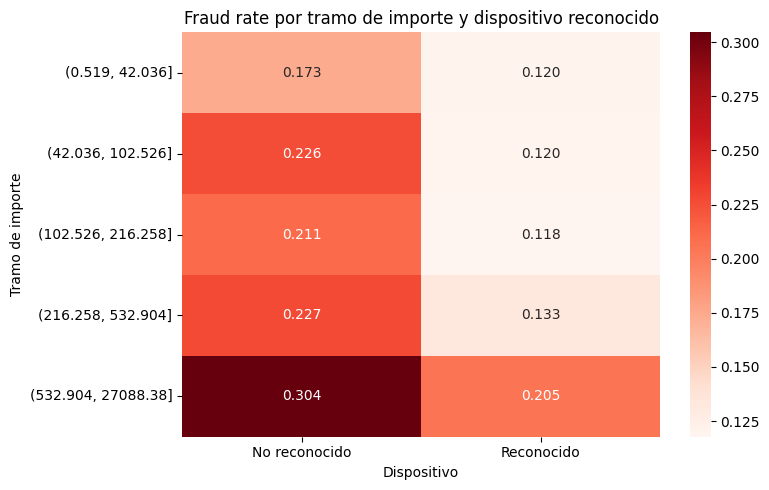

In [29]:
pivot_importe_dispositivo = df.pivot_table(
    values='IS_FRAUD',
    index='importe_tramo',
    columns='dispositivo_reconocido',
    aggfunc='mean'
)

pivot_importe_dispositivo = pivot_importe_dispositivo.rename(columns={
    0: 'No reconocido',
    1: 'Reconocido'
})

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_importe_dispositivo, cmap='Reds', annot=True, fmt='.3f')
plt.title('Fraud rate por tramo de importe y dispositivo reconocido')
plt.xlabel('Dispositivo')
plt.ylabel('Tramo de importe')
plt.tight_layout()
plt.show()

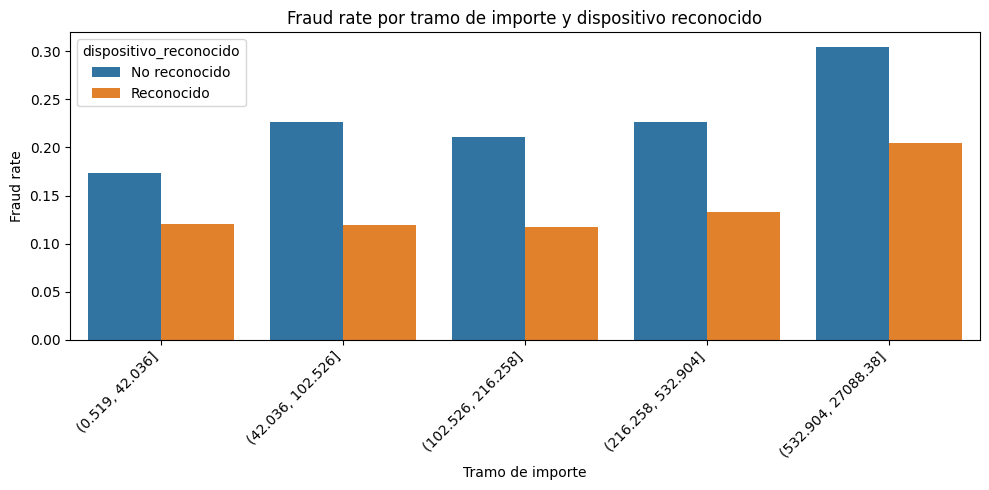

In [30]:
tabla_plot = tabla_fraud_rate.copy()
tabla_plot['dispositivo_reconocido'] = tabla_plot['dispositivo_reconocido'].map({
    0: 'No reconocido',
    1: 'Reconocido'
})

plt.figure(figsize=(10, 5))
sns.barplot(
    data=tabla_plot,
    x='importe_tramo',
    y='fraud_rate',
    hue='dispositivo_reconocido'
)
plt.title('Fraud rate por tramo de importe y dispositivo reconocido')
plt.xlabel('Tramo de importe')
plt.ylabel('Fraud rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [32]:
# Copia opcional para no ensuciar df original
df_inter = df.copy()

# Tramos necesarios
df_inter['importe_tramo'] = pd.qcut(
    df_inter['importe_transaccion'],
    q=5,
    duplicates='drop'
)

df_inter['tiempo_desde_ultima_tramo'] = pd.qcut(
    df_inter['tiempo_desde_ultima_transaccion'],
    q=5,
    duplicates='drop'
)

# Etiquetas para binarias
df_inter['is_night_label'] = df_inter['is_night'].map({
    0: 'No noche',
    1: 'Noche'
})

df_inter['dispositivo_label'] = df_inter['dispositivo_reconocido'].map({
    0: 'No reconocido',
    1: 'Reconocido'
})

df_inter['riesgo_label'] = df_inter['destino_alto_riesgo'].map({
    0: 'No alto riesgo',
    1: 'Alto riesgo'
})

In [33]:
def resumen_y_heatmap(df, fila, columna, titulo, figsize=(8, 5)):
    tabla_resumen = (
        df.groupby([fila, columna])['IS_FRAUD']
        .agg(total='size', fraud_rate='mean')
        .reset_index()
    )

    display(tabla_resumen)

    pivot = df.pivot_table(
        values='IS_FRAUD',
        index=fila,
        columns=columna,
        aggfunc='mean'
    )

    plt.figure(figsize=figsize)
    sns.heatmap(pivot, cmap='Reds', annot=True, fmt='.3f')
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

,numero_transacciones_ultima_hora,is_night_label,total,fraud_rate
0,0,No noche,971,0.159629
1,0,Noche,404,0.183168
2,1,No noche,1850,0.142162
3,1,Noche,809,0.158220
4,2,No noche,1896,0.146097
5,2,Noche,831,0.158845
6,3,No noche,1273,0.157109
7,3,Noche,507,0.142012
8,4,No noche,626,0.148562
9,4,Noche,271,0.143911


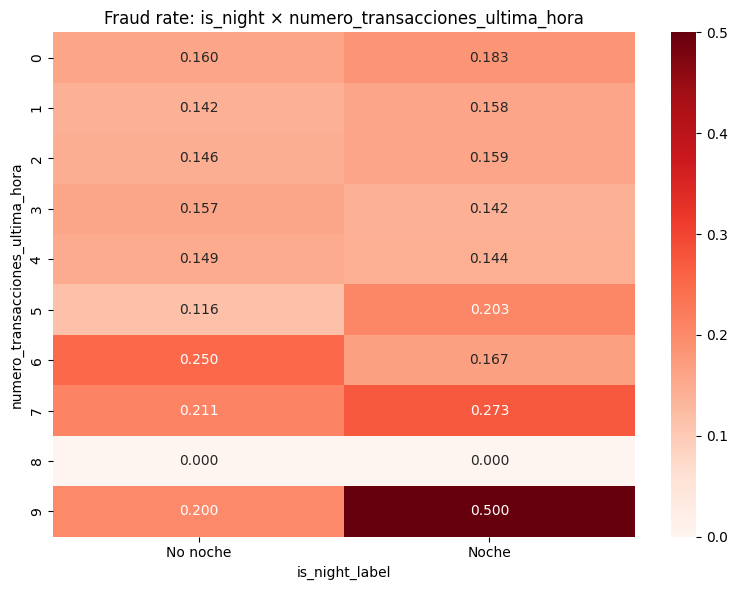

,importe_tramo,riesgo_label,total,fraud_rate
0,"(0.519, 42.036]",Alto riesgo,216,0.245370
1,"(0.519, 42.036]",No alto riesgo,1784,0.114910
2,"(42.036, 102.526]",Alto riesgo,238,0.306723
3,"(42.036, 102.526]",No alto riesgo,1762,0.113507
4,"(102.526, 216.258]",Alto riesgo,245,0.359184
5,"(102.526, 216.258]",No alto riesgo,1755,0.099145
6,"(216.258, 532.904]",Alto riesgo,238,0.336134
7,"(216.258, 532.904]",No alto riesgo,1762,0.121453
8,"(532.904, 27088.38]",Alto riesgo,252,0.420635
9,"(532.904, 27088.38]",No alto riesgo,1748,0.190503


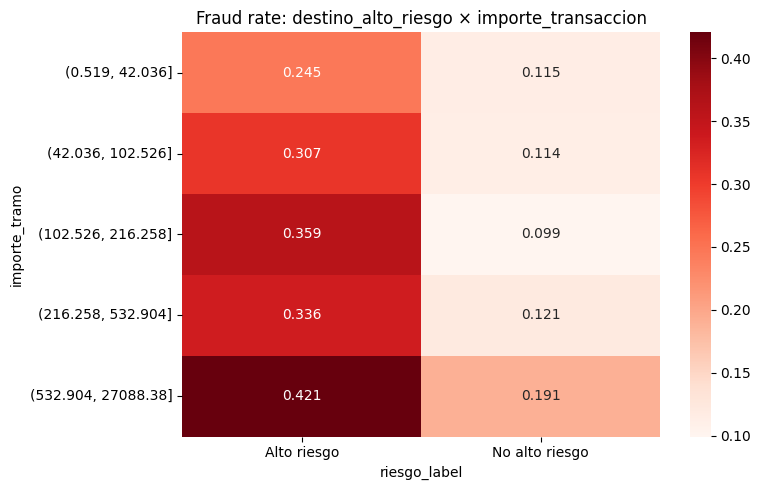

,customer_country,operacion_pais,total,fraud_rate
0,BR,BR,472,0.158898
1,BR,DE,5,0.200000
2,BR,ES,6,0.166667
3,BR,FR,8,0.500000
4,BR,GB,9,0.000000
...,...,...,...,...
59,US,FR,8,0.625000
60,US,GB,4,0.250000
61,US,IT,6,0.333333
62,US,PT,1,0.000000


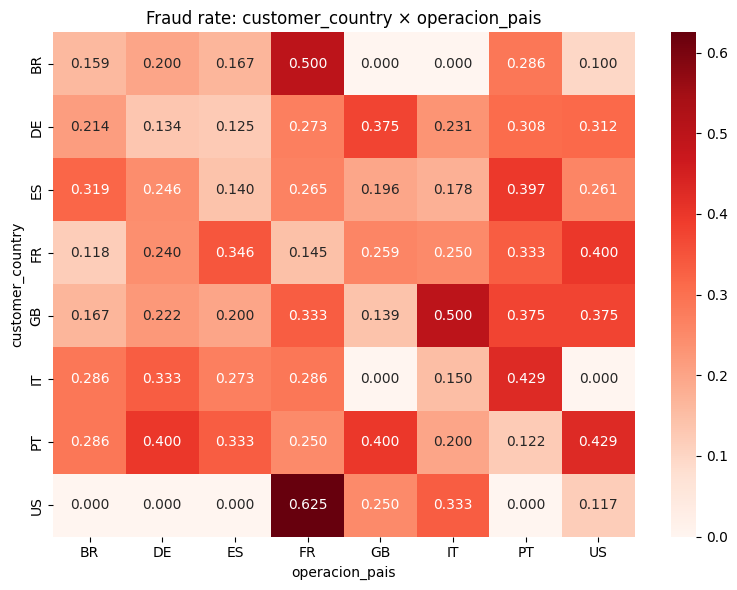

,metodo_autenticacion,dispositivo_label,total,fraud_rate
0,3DS,No reconocido,472,0.201271
1,3DS,Reconocido,2541,0.130264
2,PIN,No reconocido,581,0.234079
3,PIN,Reconocido,3428,0.136523
4,contactless,No reconocido,66,0.166667
5,contactless,Reconocido,469,0.172708
6,firma,No reconocido,231,0.264069
7,firma,Reconocido,1226,0.158238
8,huella,No reconocido,158,0.246835
9,huella,Reconocido,828,0.132850


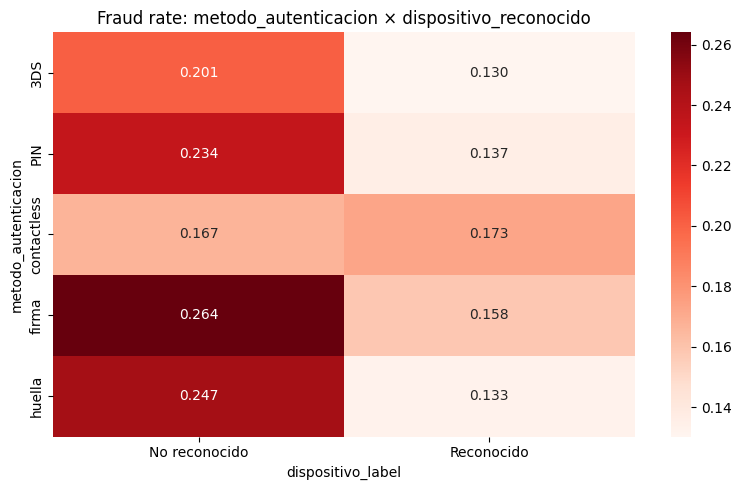

,numero_fraudes_ultimo_ano,riesgo_label,total,fraud_rate
0,0,Alto riesgo,797,0.329987
1,0,No alto riesgo,5994,0.118952
2,1,Alto riesgo,262,0.339695
3,1,No alto riesgo,1978,0.137513
4,2,Alto riesgo,97,0.402062
5,2,No alto riesgo,588,0.159864
6,3,Alto riesgo,23,0.304348
7,3,No alto riesgo,178,0.224719
8,4,Alto riesgo,8,0.250000
9,4,No alto riesgo,64,0.093750


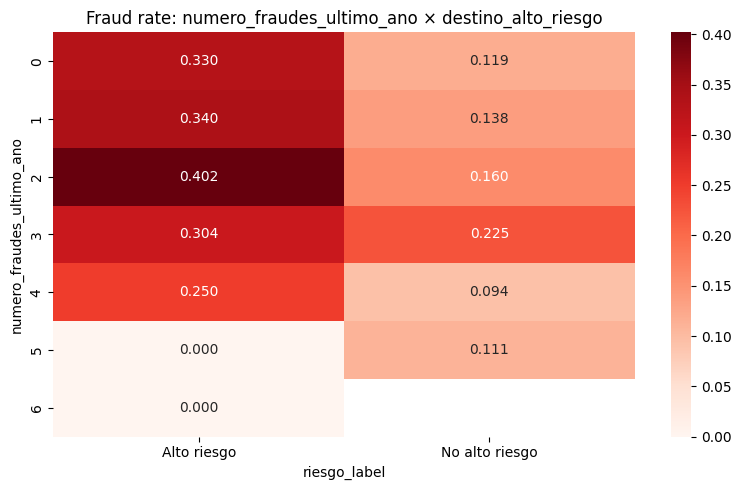

,estado_tarjeta,importe_tramo,total,fraud_rate
0,activa,"(0.519, 42.036]",1620,0.107407
1,activa,"(42.036, 102.526]",1577,0.102727
2,activa,"(102.526, 216.258]",1591,0.101194
3,activa,"(216.258, 532.904]",1596,0.119048
4,activa,"(532.904, 27088.38]",1600,0.195000
5,bloqueada,"(0.519, 42.036]",93,0.365591
6,bloqueada,"(42.036, 102.526]",88,0.386364
7,bloqueada,"(102.526, 216.258]",86,0.302326
8,bloqueada,"(216.258, 532.904]",87,0.344828
9,bloqueada,"(532.904, 27088.38]",94,0.382979


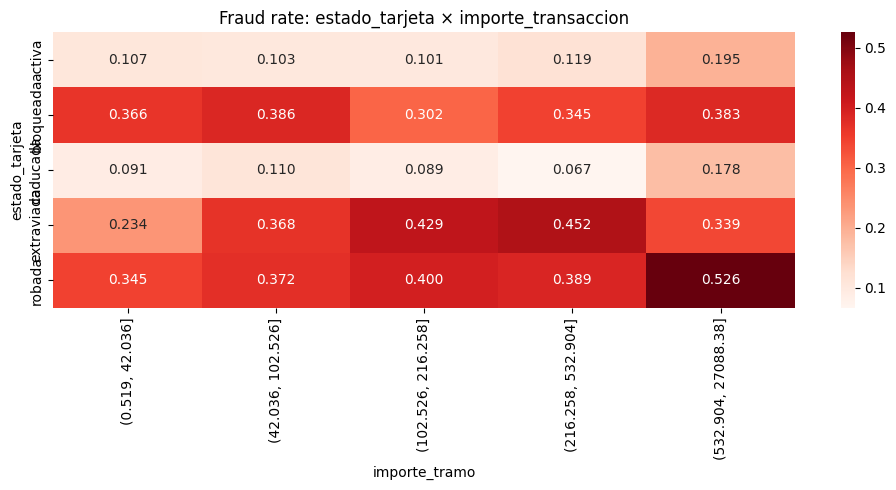

,tiempo_desde_ultima_tramo,numero_transacciones_ultima_hora,total,fraud_rate
0,"(-0.001, 27484.6]",0,527,0.172676
1,"(-0.001, 27484.6]",1,1089,0.155188
2,"(-0.001, 27484.6]",2,1107,0.147245
3,"(-0.001, 27484.6]",3,727,0.137552
4,"(-0.001, 27484.6]",4,346,0.127168
5,"(-0.001, 27484.6]",5,141,0.120567
6,"(-0.001, 27484.6]",6,44,0.204545
7,"(-0.001, 27484.6]",7,13,0.230769
8,"(-0.001, 27484.6]",8,3,0.000000
9,"(-0.001, 27484.6]",9,3,0.333333


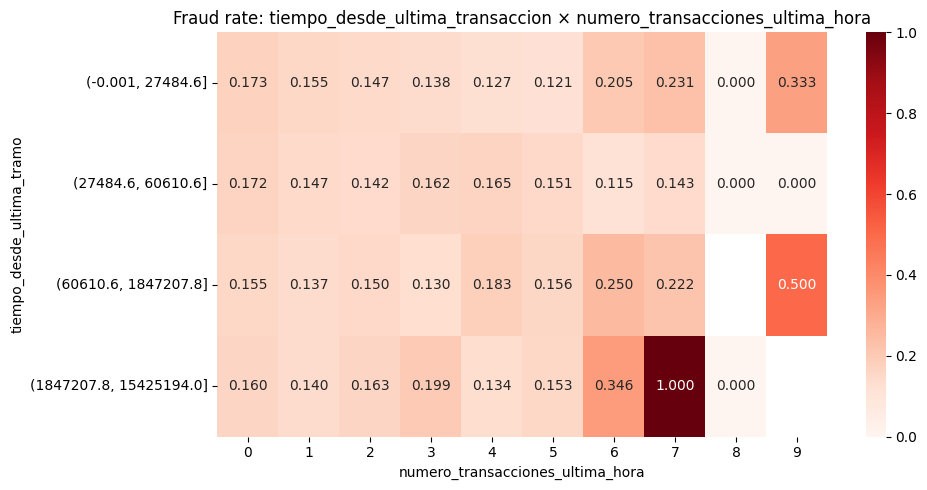

,is_night_label,riesgo_label,total,fraud_rate
0,No noche,Alto riesgo,821,0.314251
1,No noche,No alto riesgo,6187,0.127525
2,Noche,Alto riesgo,368,0.385870
3,Noche,No alto riesgo,2624,0.128430


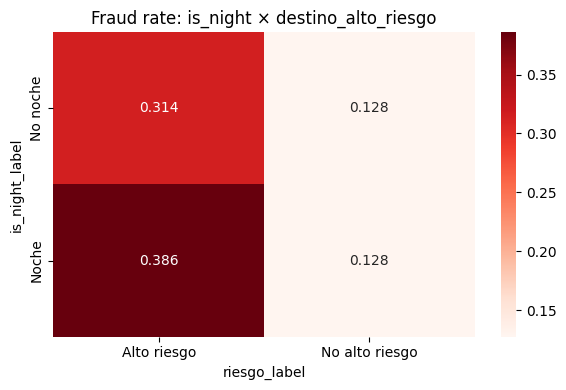

,tipo_transaccion,importe_tramo,total,fraud_rate
0,tarjeta,"(0.519, 42.036]",1421,0.108374
1,tarjeta,"(42.036, 102.526]",1411,0.115521
2,tarjeta,"(102.526, 216.258]",1408,0.114347
3,tarjeta,"(216.258, 532.904]",1415,0.142049
4,tarjeta,"(532.904, 27088.38]",1401,0.199143
5,transferencia,"(0.519, 42.036]",579,0.179620
6,transferencia,"(42.036, 102.526]",589,0.186757
7,transferencia,"(102.526, 216.258]",592,0.170608
8,transferencia,"(216.258, 532.904]",585,0.158974
9,transferencia,"(532.904, 27088.38]",599,0.267112


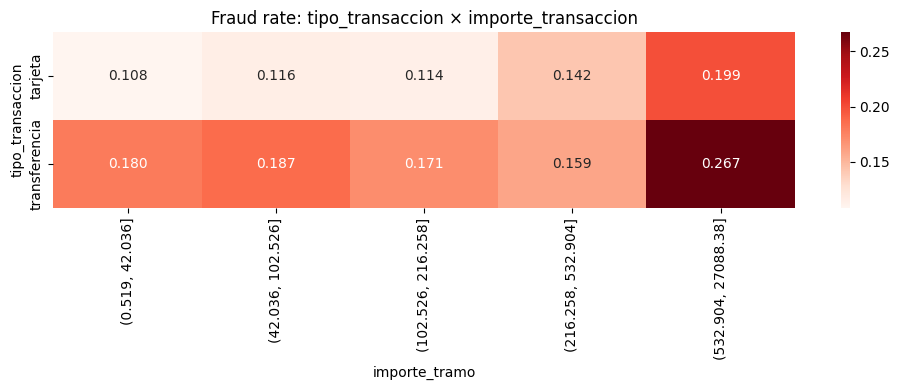

In [34]:
# 1. is_night × numero_transacciones_ultima_hora
resumen_y_heatmap(
    df_inter,
    'numero_transacciones_ultima_hora',
    'is_night_label',
    'Fraud rate: is_night × numero_transacciones_ultima_hora',
    figsize=(8, 6)
)

# 2. destino_alto_riesgo × importe_transaccion
resumen_y_heatmap(
    df_inter,
    'importe_tramo',
    'riesgo_label',
    'Fraud rate: destino_alto_riesgo × importe_transaccion',
    figsize=(8, 5)
)

# 3. customer_country × operacion_pais
resumen_y_heatmap(
    df_inter,
    'customer_country',
    'operacion_pais',
    'Fraud rate: customer_country × operacion_pais',
    figsize=(8, 6)
)

# 4. metodo_autenticacion × dispositivo_reconocido
resumen_y_heatmap(
    df_inter,
    'metodo_autenticacion',
    'dispositivo_label',
    'Fraud rate: metodo_autenticacion × dispositivo_reconocido',
    figsize=(8, 5)
)

# 5. numero_fraudes_ultimo_ano × destino_alto_riesgo
resumen_y_heatmap(
    df_inter,
    'numero_fraudes_ultimo_ano',
    'riesgo_label',
    'Fraud rate: numero_fraudes_ultimo_ano × destino_alto_riesgo',
    figsize=(8, 5)
)

# 6. estado_tarjeta × importe_transaccion
resumen_y_heatmap(
    df_inter,
    'estado_tarjeta',
    'importe_tramo',
    'Fraud rate: estado_tarjeta × importe_transaccion',
    figsize=(10, 5)
)

# 7. tiempo_desde_ultima_transaccion × numero_transacciones_ultima_hora
resumen_y_heatmap(
    df_inter,
    'tiempo_desde_ultima_tramo',
    'numero_transacciones_ultima_hora',
    'Fraud rate: tiempo_desde_ultima_transaccion × numero_transacciones_ultima_hora',
    figsize=(10, 5)
)

# 8. is_night × destino_alto_riesgo
resumen_y_heatmap(
    df_inter,
    'is_night_label',
    'riesgo_label',
    'Fraud rate: is_night × destino_alto_riesgo',
    figsize=(6, 4)
)

# 9. tipo_transaccion × importe_transaccion
resumen_y_heatmap(
    df_inter,
    'tipo_transaccion',
    'importe_tramo',
    'Fraud rate: tipo_transaccion × importe_transaccion',
    figsize=(10, 4)
)